# Motores OCR

Comparación de PaddleOCR en CPU y GPU, Tesseract y EasyOCR para extraer texto en español.

Este notebook solo lee resultados guardados. Ejecutar todas las celdas no descarga modelos, no consulta servicios y no sobrescribe las mediciones.

## Método y alcance

El bloque sintético contiene seis condiciones y configura tres repeticiones por motor. El registro conserva los promedios, sin valores individuales por repetición. El bloque real contiene tres imágenes con 5, 6 y 9 fragmentos transcritos a mano, no páginas enteras. CER y WER reales son medias macro por imagen. Cada imagen pesa lo mismo, aunque tenga distinto número de fragmentos. La búsqueda aproximada de cada fragmento permite texto adicional en la salida OCR. CER y WER miden error de caracteres y palabras. La columna histórica `precision` es 1 − CER, no precisión estadística. Los tiempos pertenecen a la ejecución guardada.

Las imágenes, las transcripciones parciales y las salidas OCR se incluyen junto al notebook. La [procedencia del dataset](dataset/README.md) recoge sus fuentes.

In [1]:
import json
import sys
from pathlib import Path


sys.dont_write_bytecode = True


YELLOW = "\033[33m"


CYAN = "\033[36m"


GREEN = "\033[32m"


RESET = "\033[0m"


PALETTE = (
    "#89b4fa",
    "#cba6f7",
    "#f38ba8",
    "#b4befe",
    "#fab387",
    "#a6e3a1",
    "#f9e2af",
    "#94e2d5",
    "#74c7ec",
    "#eba0ac",
)


def info(text: str, highlight: object = "", after: str = "") -> None:
    """Resalta un dato y devuelve el resto del mensaje al cian."""
    message = text.rstrip(". ")
    if highlight != "":
        message += f" {GREEN}{highlight}{CYAN}"
    if after:
        message += f" {after.rstrip('. ')}"
    print(f"{YELLOW}[*]{RESET} {CYAN}{message}.{RESET}")


def read_json(path: Path) -> dict:
    with path.open(encoding="utf-8-sig") as stream:
        return json.load(stream)


def markdown_table(rows: list[dict], columns: dict[str, str]) -> str:
    from tabulate import tabulate

    return tabulate(
        [
            [
                f"{row[key]:.4f}".rstrip("0").rstrip(".")
                if isinstance(row[key], float)
                else row[key]
                for key in columns
            ]
            for row in rows
        ],
        headers=list(columns.values()),
        tablefmt="github",
        disable_numparse=True,
    )


def show_table(rows: list[dict], columns: dict[str, str]) -> None:
    from IPython.display import Markdown, display

    display(Markdown(markdown_table(rows, columns)))


def plot_metrics(rows: list[dict], metrics: list[tuple[str, str]], title: str):
    """Dos paneles horizontales para conservar etiquetas legibles."""
    import matplotlib as mpl
    import matplotlib.pyplot as plt

    style = {
        "font.family": "DejaVu Sans",
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.titleweight": "bold",
        "axes.titlepad": 14,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.spines.left": False,
        "axes.edgecolor": "#bcc2cc",
        "axes.labelcolor": "#414654",
        "xtick.color": "#565e6d",
        "ytick.color": "#252a34",
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "svg.fonttype": "none",
    }
    with mpl.rc_context(style):
        height = max(3.7, len(rows) * 0.42 + 1.4)
        figure, axes = plt.subplots(
            1,
            len(metrics),
            figsize=(13, height),
            layout="constrained",
            squeeze=False,
            sharey=True,
        )
        labels = [str(row["label"]) for row in rows]
        colors = [row.get("color", PALETTE[index % len(PALETTE)]) for index, row in enumerate(rows)]
        for axis, (key, caption) in zip(axes[0], metrics, strict=True):
            values = [row[key] for row in rows]
            bars = axis.barh(range(len(labels)), values, color=colors, height=0.64, zorder=3)
            axis.set_yticks(range(len(labels)), labels)
            axis.set_title(caption, loc="left")
            axis.set_axisbelow(True)
            axis.grid(axis="x", color="#e9ebef", linewidth=0.8)
            axis.tick_params(axis="y", length=0, pad=8)
            axis.margins(x=0.2)
            axis.bar_label(
                bars,
                labels=[f"{value:.3f}".rstrip("0").rstrip(".") for value in values],
                padding=5,
                fontsize=9,
            )
        axes[0, 0].set_ylim(len(labels) - 0.5, -0.5)
        figure.suptitle(title, fontsize=15, weight="bold", color="#252a34")
    plt.close(figure)
    return figure


relative = Path("ocr/engines")
here = Path.cwd().resolve()
benchmarks = next(
    parent / "docs/benchmarks"
    for parent in (here, *here.parents)
    if (parent / "docs/benchmarks" / relative / "results.json").is_file()
)

study = benchmarks / relative
data = read_json(study / "results.json")
info("Resultados guardados de", relative.as_posix(), "cargados")

synthetic = [dict(row, label=row["nombre"]) for row in data["resumen"]]
real_data = read_json(study / "results_real.json")
real = [dict(row, label=row["nombre"]) for row in real_data["resumen"]]

[*] Resultados guardados de ocr/engines cargados.


## Resultados

Los JSON conservan las mediciones originales.

### Imágenes sintéticas

In [2]:
show_table(
    synthetic,
    {
        "label": "Motor",
        "cer_medio": "CER ↓",
        "wer_medio": "WER ↓",
        "precision": "1 - CER ↑",
        "velocidad_s": "Segundos ↓",
    },
)

| Motor         | CER ↓   | WER ↓   | 1 - CER ↑   | Segundos ↓   |
|---------------|---------|---------|-------------|--------------|
| PaddleOCR CPU | 0.1144  | 0.1926  | 0.8856      | 2.3457       |
| PaddleOCR GPU | 0.1144  | 0.1926  | 0.8856      | 0.0296       |
| Tesseract     | 0.0882  | 0.1423  | 0.9118      | 0.1761       |
| EasyOCR       | 0.1329  | 0.2205  | 0.8671      | 0.7394       |

### Imágenes reales

In [3]:
show_table(
    real,
    {
        "label": "Motor",
        "cer_medio": "CER ↓",
        "wer_medio": "WER ↓",
        "precision": "1 - CER ↑",
        "velocidad_s": "Segundos ↓",
    },
)

| Motor         | CER ↓   | WER ↓   | 1 - CER ↑   | Segundos ↓   |
|---------------|---------|---------|-------------|--------------|
| PaddleOCR CPU | 0.1092  | 0.1595  | 0.8908      | 116.5511     |
| PaddleOCR GPU | 0.1092  | 0.1595  | 0.8908      | 11.4023      |
| Tesseract     | 0.2055  | 0.336   | 0.7945      | 6.9156       |
| EasyOCR       | 0.2119  | 0.2602  | 0.7881      | 27.4713      |

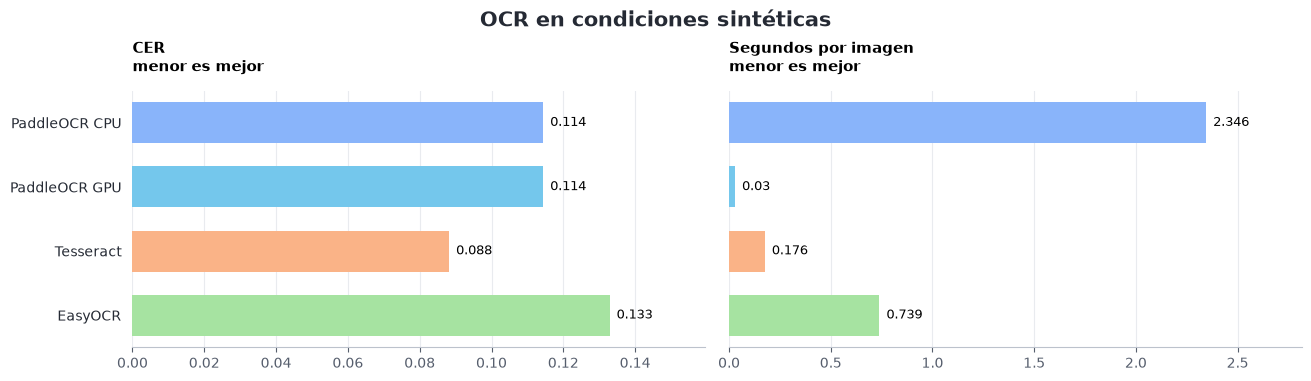

In [4]:
figure_0 = plot_metrics(
    synthetic,
    [
        ("cer_medio", "CER\nmenor es mejor"),
        ("velocidad_s", "Segundos por imagen\nmenor es mejor"),
    ],
    "OCR en condiciones sintéticas",
)
figure_0

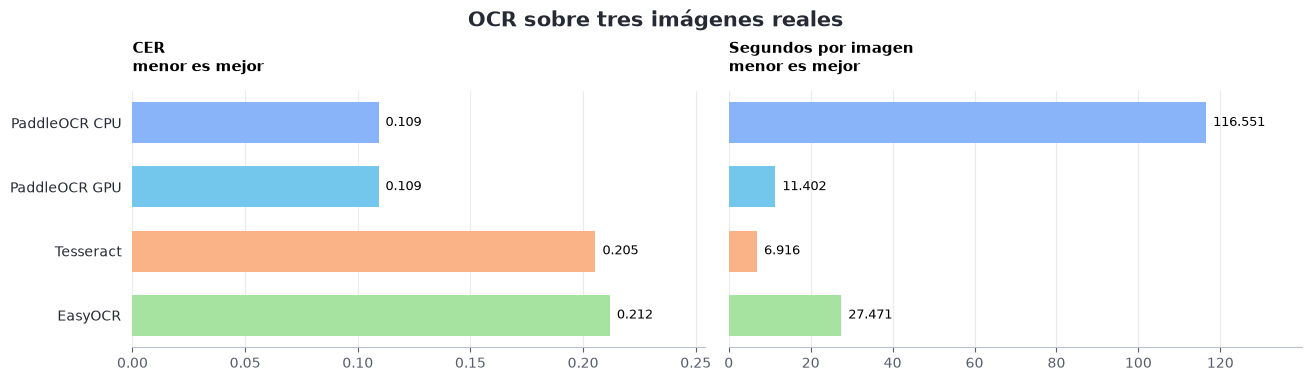

In [5]:
figure_1 = plot_metrics(
    real,
    [
        ("cer_medio", "CER\nmenor es mejor"),
        ("velocidad_s", "Segundos por imagen\nmenor es mejor"),
    ],
    "OCR sobre tres imágenes reales",
)
figure_1

## Conclusiones

PaddleOCR obtiene el menor error medio en el conjunto de imágenes reales. Con
GPU tarda unos 11 segundos por imagen, frente a 117 en CPU, con el mismo error.
Tesseract tarda unos 7 segundos, pero su error medio es mayor.

En las imágenes sintéticas gana Tesseract. La muestra real es pequeña y solo
tiene fragmentos transcritos, así que ningún motor puede darse por mejor para
todos los manuales.

## Archivos y reproducción

`measure.py` conserva el método de medición y requiere una ejecución explícita con un directorio nuevo. Consulta el [índice](../../README.md) antes de medir. Las dependencias actuales no garantizan repetir exactamente el entorno histórico ni sus tiempos.